In [120]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix 
from sklearn.inspection import DecisionBoundaryDisplay

In [121]:
df = np.loadtxt("artificial2d.csv", delimiter = ",", skiprows = 1)

In [122]:
np.random.seed(2)
np.random.shuffle(df)

In [123]:
X = df[:,[0,1]]
y = df[:,2]

n = X.shape[0]
m = y.shape[0]

In [124]:
def standardize (V):

    df_padronizado = np.zeros(V.shape)

    for i in range (V.shape[1]):

      media = np.mean(V[:,i])
      desv = np.std(V[:,i])
      df_padronizado[:,i] = (V[:,i] - media) / desv

    return (df_padronizado)

In [125]:
df_padronizado = standardize(X)

In [126]:
X_treino =  df_padronizado[:int(0.7*n)]
X_teste = df_padronizado[int(0.7*n):]
y_treino = y[:int(0.7*m)]
y_teste = y[int(0.7*m):]

In [127]:
regressao = LogisticRegression(penalty = None)

regressao.fit(X_treino, y_treino)
predicao = regressao.predict(X_teste)

print (predicao)

[1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 1. 0. 1. 1.
 0. 0. 0. 1. 0. 0.]


In [128]:
cm = confusion_matrix(y_teste, predicao)

print("Matriz de Confusão:", f'\n')

vp = cm[1, 1]
print("Verdadeiro Positivo:", vp)

fn = cm[1, 0]
print("Falso Negativo:", fn)

fp = cm[0, 1]
print("Falso Positivo:", fp)

vn = cm[0, 0]
print("Verdadeiro Negativo:", vn, f'\n')

Accuracy = (vp + vn) / (vp + vn + fp + fn)
print ("Accuracy:", Accuracy, f'\n')

Recall = vp / (vp + fn)
print ("Recall:", Recall, f'\n')

Precision = vp / (vp + fp)
print ("Precision:", Precision, f'\n')


Matriz de Confusão: 

Verdadeiro Positivo: 15
Falso Negativo: 2
Falso Positivo: 0
Verdadeiro Negativo: 13 

Accuracy: 0.9333333333333333 

Recall: 0.8823529411764706 

Precision: 1.0 



C:\Users\David\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\inspection\_plot\decision_boundary.py:221: UserWarning: The following kwargs were not used by contour: 'shading'
  self.surface_ = plot_func(self.xx0, self.xx1, self.response, **kwargs)


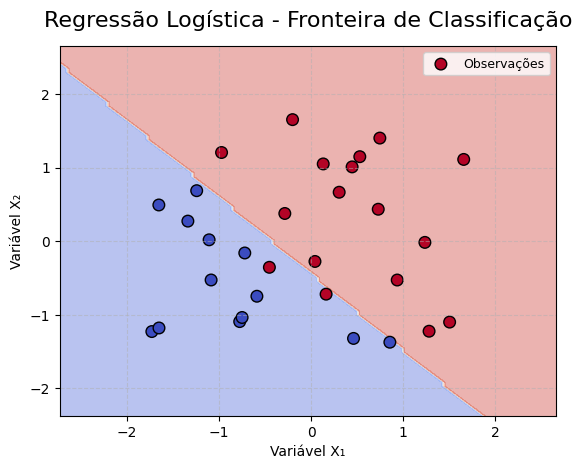

In [129]:
DecisionBoundaryDisplay.from_estimator(regressao, X_teste, response_method = "predict", cmap = plt.cm.coolwarm, alpha = 0.4, shading = 'auto')

plt.scatter(X_teste[:, 0], X_teste[:, 1], c = y_teste, cmap = plt.cm.coolwarm, edgecolor = 'k', s=70, linewidth = 1, label = "Observações")

plt.title("Regressão Logística - Fronteira de Classificação", fontsize=16, y=1.03)
plt.xlabel("Variável X₁", fontsize = 10)
plt.ylabel("Variável X₂", fontsize = 10)
plt.legend(fontsize=9)
plt.grid(True, linestyle = '--', alpha = 0.5)
plt.show()